# Kalman Filter Assessment for Rootzone pH and EC

This notebook evaluates simple walk-forward Kalman models built directly from `master.csv`, without `XGBoost`.

## Short answer

- For `pH`, a simple **control-input Kalman filter** can use the previous root-zone state plus interval climate features such as temperature, humidity, `VPD`, `ET0`, and soil temperature. In this dataset it reaches about **MAE 0.367** and **R? 0.915**, which is close to the pure seasonal Kalman baseline but still behind the committed `V8` exports.
- For `EC`, the strongest Kalman result is still the **tuned local-level log filter** that mainly uses the previous `EC` state. Adding control inputs from irrigation and fertigation was tested, but it did not beat the simpler filter.

The rest of the notebook shows the walk-forward benchmark, the no-`XGBoost` Kalman candidates, and the side-by-side export comparison.


In [1]:
from pathlib import Path
import html
import pandas as pd
import numpy as np
from IPython.display import HTML, SVG, display

ROOT = Path.cwd().resolve()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
MASTER_PATH = ROOT / "data" / "processed" / "master.csv"
EXPORT_DIR = ROOT / "scripts" / "exports"


def display_df(df, rows=None):
    show_df = df.head(rows) if rows is not None else df
    display(HTML(show_df.to_html(index=False, float_format=lambda x: f"{x:.3f}" if isinstance(x, (int, float, np.floating)) else str(x))))


def _palette(label):
    if label.startswith("v7"):
        return "#1f77b4"
    if label.startswith("kalman_selected"):
        return "#ff7f0e"
    if label.startswith("kalman_best_holdout"):
        return "#9467bd"
    return "#7f7f7f"


def svg_metric_bar(frame, metric, title, lower_is_better=True, width=920, height=360):
    data = frame.copy().reset_index(drop=True)
    margin_left, margin_right, margin_top, margin_bottom = 70, 24, 54, 72
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom
    max_val = float(max(data[metric].max() * 1.15, 1e-6))
    bar_w = plot_w / max(len(data), 1)
    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">']
    lines.append(f'<rect width="{width}" height="{height}" fill="white"/>')
    lines.append(f'<text x="{width/2}" y="28" text-anchor="middle" font-size="20" font-family="Arial" fill="#111">{html.escape(title)}</text>')
    lines.append(f'<text x="{width/2}" y="48" text-anchor="middle" font-size="12" font-family="Arial" fill="#555">{"Lower is better" if lower_is_better else "Higher is better"}</text>')
    lines.append(f'<line x1="{margin_left}" y1="{height-margin_bottom}" x2="{width-margin_right}" y2="{height-margin_bottom}" stroke="#444"/>')
    lines.append(f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{height-margin_bottom}" stroke="#444"/>')
    for i in range(5):
        value = max_val * i / 4.0
        y = height - margin_bottom - plot_h * i / 4.0
        lines.append(f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width-margin_right}" y2="{y:.1f}" stroke="#e6e6e6"/>')
        lines.append(f'<text x="{margin_left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11" font-family="Arial" fill="#555">{value:.2f}</text>')
    for idx, row in data.iterrows():
        value = float(row[metric])
        x = margin_left + idx * bar_w + bar_w * 0.16
        y = height - margin_bottom - (value / max_val) * plot_h
        h = height - margin_bottom - y
        color = _palette(str(row["model"]))
        lines.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_w*0.68:.1f}" height="{h:.1f}" rx="4" fill="{color}" opacity="0.9"/>')
        lines.append(f'<text x="{x + bar_w*0.34:.1f}" y="{y-6:.1f}" text-anchor="middle" font-size="11" font-family="Arial" fill="#222">{value:.3f}</text>')
        label = str(row["model"]).replace("kalman_selected_", "kalman cv: ").replace("kalman_best_holdout_", "kalman best: ")
        lines.append(f'<text transform="translate({x + bar_w*0.34:.1f},{height-margin_bottom+16}) rotate(28)" font-size="11" font-family="Arial" fill="#222">{html.escape(label)}</text>')
    lines.append("</svg>")
    return "".join(lines)


def svg_gap_timeline(gaps, title, width=920, height=320):
    gaps = np.asarray(gaps, dtype=float)
    margin_left, margin_right, margin_top, margin_bottom = 70, 20, 40, 48
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom
    max_gap = max(float(gaps.max()), 1.0)
    y_max = np.log10(1.0 + max_gap)

    def x_pos(i):
        return margin_left + plot_w * i / max(len(gaps) - 1, 1)

    def y_pos(v):
        return margin_top + plot_h * (1.0 - np.log10(1.0 + max(v, 0.0)) / y_max)

    points = " ".join(f"{x_pos(i):.1f},{y_pos(v):.1f}" for i, v in enumerate(gaps))
    med = float(np.median(gaps))
    p90 = float(np.quantile(gaps, 0.9))
    ticks = [0.5, 2, 6, 24, 72, 168, max_gap]
    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">']
    lines.append(f'<rect width="{width}" height="{height}" fill="white"/>')
    lines.append(f'<text x="{width/2}" y="24" text-anchor="middle" font-size="20" font-family="Arial" fill="#111">{html.escape(title)}</text>')
    lines.append(f'<text x="{width/2}" y="42" text-anchor="middle" font-size="12" font-family="Arial" fill="#555">Y axis uses log10(1 + gap_hours) so rare very long gaps stay visible.</text>')
    lines.append(f'<line x1="{margin_left}" y1="{height-margin_bottom}" x2="{width-margin_right}" y2="{height-margin_bottom}" stroke="#444"/>')
    lines.append(f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{height-margin_bottom}" stroke="#444"/>')
    for tick in ticks:
        y = y_pos(tick)
        lines.append(f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width-margin_right}" y2="{y:.1f}" stroke="#ececec"/>')
        lines.append(f'<text x="{margin_left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11" font-family="Arial" fill="#555">{tick:.1f}</text>')
    lines.append(f'<polyline fill="none" stroke="#1f77b4" stroke-width="2" points="{points}"/>')
    for ref, label, color in [(med, "median", "#ff7f0e"), (p90, "p90", "#d62728")]:
        y = y_pos(ref)
        lines.append(f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width-margin_right}" y2="{y:.1f}" stroke="{color}" stroke-dasharray="6,4"/>')
        lines.append(f'<text x="{width-margin_right}" y="{y-6:.1f}" text-anchor="end" font-size="11" font-family="Arial" fill="{color}">{label}: {ref:.1f} h</text>')
    lines.append("</svg>")
    return "".join(lines)


def svg_error_timeline(frame, title, kalman_col="kalman_abs_err", v7_col="v7_abs_err", width=920, height=320):
    data = frame.copy().reset_index(drop=True)
    margin_left, margin_right, margin_top, margin_bottom = 70, 20, 44, 52
    plot_w = width - margin_left - margin_right
    plot_h = height - margin_top - margin_bottom
    max_err = max(float(data[[kalman_col, v7_col]].to_numpy().max()) * 1.1, 1e-6)

    def x_pos(i):
        return margin_left + plot_w * i / max(len(data) - 1, 1)

    def y_pos(v):
        return margin_top + plot_h * (1.0 - v / max_err)

    kalman_points = " ".join(f"{x_pos(i):.1f},{y_pos(v):.1f}" for i, v in enumerate(data[kalman_col]))
    v7_points = " ".join(f"{x_pos(i):.1f},{y_pos(v):.1f}" for i, v in enumerate(data[v7_col]))
    lines = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">']
    lines.append(f'<rect width="{width}" height="{height}" fill="white"/>')
    lines.append(f'<text x="{width/2}" y="24" text-anchor="middle" font-size="20" font-family="Arial" fill="#111">{html.escape(title)}</text>')
    lines.append(f'<line x1="{margin_left}" y1="{height-margin_bottom}" x2="{width-margin_right}" y2="{height-margin_bottom}" stroke="#444"/>')
    lines.append(f'<line x1="{margin_left}" y1="{margin_top}" x2="{margin_left}" y2="{height-margin_bottom}" stroke="#444"/>')
    for i in range(5):
        value = max_err * i / 4.0
        y = height - margin_bottom - plot_h * i / 4.0
        lines.append(f'<line x1="{margin_left}" y1="{y:.1f}" x2="{width-margin_right}" y2="{y:.1f}" stroke="#ececec"/>')
        lines.append(f'<text x="{margin_left-8}" y="{y+4:.1f}" text-anchor="end" font-size="11" font-family="Arial" fill="#555">{value:.2f}</text>')
    lines.append(f'<polyline fill="none" stroke="#ff7f0e" stroke-width="2" points="{kalman_points}"/>')
    lines.append(f'<polyline fill="none" stroke="#1f77b4" stroke-width="2" points="{v7_points}"/>')
    lines.append(f'<rect x="{margin_left}" y="{height-30}" width="14" height="14" fill="#ff7f0e"/>')
    lines.append(f'<text x="{margin_left+20}" y="{height-18}" font-size="12" font-family="Arial" fill="#222">Kalman absolute error</text>')
    lines.append(f'<rect x="{margin_left+210}" y="{height-30}" width="14" height="14" fill="#1f77b4"/>')
    lines.append(f'<text x="{margin_left+230}" y="{height-18}" font-size="12" font-family="Arial" fill="#222">V7 absolute error</text>')
    lines.append("</svg>")
    return "".join(lines)


## Benchmark Implementation

The next cell contains the same benchmark logic that was previously in the `.py` script. It builds label-to-label intervals, tests several Kalman-style candidates, selects models using only pre-holdout CV, and writes comparison artifacts into `scripts/exports`.


In [2]:
from math import pi

import numpy as np
import pandas as pd

PH_EVAL_START = 55
EC_EVAL_START = 40

ACID_FERTS = ["Phosphoric acid[mg]-H3PO4"]
SALT_FERTS = [
    "Monopotassium Phosphate[mg] -KH2PO4",
    "Potassium Chloride[mg] - KCL",
    "Kortin [mg]",
    "Ammonium Nitrate [mg] -NH4NO3",
    "Gypsum - CaSO4*2H2O [mg]",
]

LOG_LIKE_FEATURES = {
    "gap_hours",
    "et0_per_hour",
    "irr_weighted",
    "acid_weighted",
    "salt_weighted",
    "hrs_since_irr",
    "hrs_since_fert",
    "fert_per_irr",
    "acid_per_irr",
    "leaching_ratio",
}

PH_CONTROL_FEATURES = [
    "prev_ec",
    "gap_hours",
    "sin_delta",
    "cos_delta",
    "temp_mean",
    "rh_mean",
    "vpd_mean",
    "et0_per_hour",
    "soil_temp_mean",
]

EC_CONTROL_FEATURES = [
    "prev_ph",
    "gap_hours",
    "temp_mean",
    "rh_mean",
    "vpd_mean",
    "et0_per_hour",
    "irr_weighted",
    "acid_weighted",
    "salt_weighted",
]


def mae(y, pred):
    y_arr = np.asarray(y, dtype=float)
    p_arr = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs(y_arr - p_arr)))


def rmse(y, pred):
    y_arr = np.asarray(y, dtype=float)
    p_arr = np.asarray(pred, dtype=float)
    return float(np.sqrt(np.mean((y_arr - p_arr) ** 2)))


def r2(y, pred):
    y_arr = np.asarray(y, dtype=float)
    p_arr = np.asarray(pred, dtype=float)
    ss_tot = float(np.sum((y_arr - y_arr.mean()) ** 2))
    if ss_tot <= 0.0:
        return np.nan
    return float(1.0 - np.sum((y_arr - p_arr) ** 2) / ss_tot)


def eval_metrics(frame: pd.DataFrame) -> dict:
    return {
        "mae": mae(frame["true"], frame["pred"]),
        "rmse": rmse(frame["true"], frame["pred"]),
        "r2": r2(frame["true"], frame["pred"]),
        "naive_mae": mae(frame["true"], frame["naive"]),
        "n_eval": int(len(frame)),
    }


def _to_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(0.0)


def _sum_columns(seg: pd.DataFrame, columns: list[str]) -> pd.Series:
    if len(seg) == 0:
        return pd.Series(dtype=float)
    out = pd.Series(0.0, index=seg.index)
    for col in columns:
        if col in seg.columns:
            out = out.add(_to_num(seg[col]), fill_value=0.0)
    return out


def load_master() -> pd.DataFrame:
    df = pd.read_csv(MASTER_PATH)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df.sort_values("timestamp").set_index("timestamp")


def build_label_frame(master_df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    labels = master_df.loc[master_df[target_col].notna(), [target_col]].reset_index().copy()
    labels.columns = ["timestamp", "value"]
    return labels


def build_target_stats(labels: pd.DataFrame, eval_start_idx: int, target: str) -> dict:
    gaps = labels["timestamp"].diff().dt.total_seconds().div(3600.0).dropna()
    return {
        "target": target,
        "n_labels": int(len(labels)),
        "n_eval": int(max(len(labels) - eval_start_idx, 0)),
        "eval_start": pd.Timestamp(labels.loc[eval_start_idx, "timestamp"]),
        "mean_gap_hours": float(gaps.mean()),
        "median_gap_hours": float(gaps.median()),
        "p90_gap_hours": float(gaps.quantile(0.9)),
        "max_gap_hours": float(gaps.max()),
    }


def build_interval_feature_rows(master_df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    target_idx = master_df.index[master_df[target_col].notna()].tolist()
    rows = []
    for j in range(1, len(target_idx)):
        t0 = pd.Timestamp(target_idx[j - 1])
        t1 = pd.Timestamp(target_idx[j])
        seg = master_df.loc[(master_df.index >= t0) & (master_df.index < t1)].copy()
        gap_h = float((t1 - t0).total_seconds() / 3600.0)
        safe_gap_h = max(gap_h, 1e-6)

        time_to_t1 = ((t1 - seg.index).total_seconds() / 3600.0).to_numpy() if len(seg) else np.array([])
        weights = np.exp(-0.34 * time_to_t1) if len(seg) else np.array([])

        temp = _to_num(seg["internal_air_temp_c"]) if "internal_air_temp_c" in seg.columns else pd.Series(dtype=float)
        rh = _to_num(seg["internal_rh_%"]) if "internal_rh_%" in seg.columns else pd.Series(dtype=float)
        et0 = _to_num(seg["ET0"]) if "ET0" in seg.columns else pd.Series(dtype=float)
        rad = _to_num(seg["internal_radiation"]) if "internal_radiation" in seg.columns else pd.Series(dtype=float)
        soil = _to_num(seg["soil_temp_pred"]) if "soil_temp_pred" in seg.columns else pd.Series(dtype=float)
        irr = _to_num(seg["irrigation_ml_current"]) if "irrigation_ml_current" in seg.columns else pd.Series(dtype=float)
        fert_acid = _sum_columns(seg, ACID_FERTS)
        fert_salt = _sum_columns(seg, SALT_FERTS)
        fert_total = fert_acid.add(fert_salt, fill_value=0.0) if len(seg) else pd.Series(dtype=float)

        if len(seg) and len(temp) and len(rh):
            es = 0.6108 * np.exp((17.27 * temp) / (temp + 237.3))
            vpd = es * (1.0 - rh / 100.0)
        else:
            vpd = pd.Series(dtype=float)

        irr_events = irr[irr > 0].index if len(irr) else []
        fert_events = fert_total[fert_total > 0].index if len(fert_total) else []

        h0 = t0.hour + t0.minute / 60.0 + t0.second / 3600.0
        h1 = t1.hour + t1.minute / 60.0 + t1.second / 3600.0
        a0 = 2.0 * pi * h0 / 24.0
        a1 = 2.0 * pi * h1 / 24.0

        rows.append({
            "timestamp": t1,
            "prev_timestamp": t0,
            "gap_hours": gap_h,
            "prev_value": float(master_df.loc[t0, target_col]),
            "value": float(master_df.loc[t1, target_col]),
            "delta": float(master_df.loc[t1, target_col] - master_df.loc[t0, target_col]),
            "prev_ph": float(master_df.loc[t0, "ph"]),
            "prev_ec": float(master_df.loc[t0, "ec_ms"]),
            "sin_delta": float(np.sin(a1) - np.sin(a0)),
            "cos_delta": float(np.cos(a1) - np.cos(a0)),
            "temp_mean": float(temp.mean()) if len(temp) else 0.0,
            "temp_trend": float(temp.iloc[-1] - temp.iloc[0]) if len(temp) > 1 else 0.0,
            "rh_mean": float(rh.mean()) if len(rh) else 0.0,
            "rh_trend": float(rh.iloc[-1] - rh.iloc[0]) if len(rh) > 1 else 0.0,
            "vpd_mean": float(vpd.mean()) if len(vpd) else 0.0,
            "et0_per_hour": float(et0.sum() / safe_gap_h) if len(et0) else 0.0,
            "rad_mean": float(rad.mean()) if len(rad) else 0.0,
            "soil_temp_mean": float(soil.mean()) if len(soil) else 0.0,
            "soil_temp_trend": float(soil.iloc[-1] - soil.iloc[0]) if len(soil) > 1 else 0.0,
            "irr_weighted": float((irr.to_numpy() * weights).sum()) if len(irr) else 0.0,
            "hrs_since_irr": float((t1 - irr_events.max()).total_seconds() / 3600.0) if len(irr_events) else gap_h,
            "acid_weighted": float((fert_acid.to_numpy() * weights).sum()) if len(fert_acid) else 0.0,
            "salt_weighted": float((fert_salt.to_numpy() * weights).sum()) if len(fert_salt) else 0.0,
            "hrs_since_fert": float((t1 - fert_events.max()).total_seconds() / 3600.0) if len(fert_events) else gap_h,
            "fert_per_irr": float(fert_total.sum() / (irr.sum() + 1.0)) if len(seg) else 0.0,
            "acid_per_irr": float(fert_acid.sum() / (irr.sum() + 1.0)) if len(seg) else 0.0,
            "leaching_ratio": float(irr.sum() / (et0.sum() + 1e-3)) if len(seg) else 0.0,
        })
    return pd.DataFrame(rows)


def hour_basis(ts: pd.Timestamp) -> np.ndarray:
    hour = ts.hour + ts.minute / 60.0 + ts.second / 3600.0
    angle = 2.0 * pi * hour / 24.0
    return np.array([1.0, np.sin(angle), np.cos(angle)], dtype=float)


def recency_weights(times: pd.Series, half_life_days: float | None) -> np.ndarray:
    if half_life_days is None:
        return np.ones(len(times), dtype=float)
    timestamps = pd.to_datetime(times)
    age_days = (timestamps.max() - timestamps).dt.total_seconds().to_numpy() / 86400.0
    return np.exp(-np.log(2.0) * age_days / half_life_days)


def transform_features(frame: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    X = frame[feature_cols].copy().astype(float)
    for col in feature_cols:
        if col in LOG_LIKE_FEATURES:
            vals = X[col].to_numpy(dtype=float)
            X[col] = np.sign(vals) * np.log1p(np.abs(vals))
    return X


def fit_ridge(X_df: pd.DataFrame, y: pd.Series | np.ndarray, alpha: float, weights: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    X = X_df.to_numpy(dtype=float)
    y_arr = np.asarray(y, dtype=float)
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma < 1e-9] = 1.0
    Xs = (X - mu) / sigma
    Xaug = np.column_stack([np.ones(len(Xs)), Xs])
    if weights is None:
        lhs = Xaug.T @ Xaug
        rhs = Xaug.T @ y_arr
    else:
        w = np.asarray(weights, dtype=float)
        w = w / max(w.mean(), 1e-9)
        W = np.sqrt(w)[:, None]
        lhs = (Xaug * W).T @ (Xaug * W)
        rhs = (Xaug * W).T @ (y_arr * W[:, 0])
    reg = np.diag(np.r_[0.0, np.full(X_df.shape[1], alpha)])
    beta = np.linalg.pinv(lhs + reg) @ rhs
    return beta, mu, sigma


def predict_ridge(X_df: pd.DataFrame, beta: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    X = X_df.to_numpy(dtype=float)
    Xs = (X - mu) / sigma
    Xaug = np.column_stack([np.ones(len(Xs)), Xs])
    return Xaug @ beta


def run_seasonal24h(labels: pd.DataFrame, start_eval_idx: int, end_eval_idx: int, q_level_scale: float, q_season_scale: float, r_scale: float) -> pd.DataFrame:
    diff_var = max(float(np.var(labels["value"].diff().dropna().to_numpy(dtype=float))), 1e-6)
    q_level = diff_var * q_level_scale
    q_season = diff_var * q_season_scale
    r = diff_var * r_scale

    x = np.array([float(labels.loc[0, "value"]), 0.0, 0.0], dtype=float)
    P = np.eye(3, dtype=float)
    rows = []

    for label_idx in range(0, end_eval_idx + 1):
        timestamp = pd.Timestamp(labels.loc[label_idx, "timestamp"])
        H = hour_basis(timestamp)
        y_true = float(labels.loc[label_idx, "value"])
        if label_idx == 0:
            x_prior = x.copy()
            P_prior = P.copy()
            dt = 0.0
        else:
            prev_time = pd.Timestamp(labels.loc[label_idx - 1, "timestamp"])
            dt = float((timestamp - prev_time).total_seconds() / 3600.0)
            Q = np.diag([
                q_level * max(dt, 1e-4),
                q_season * max(dt / 24.0, 1e-4),
                q_season * max(dt / 24.0, 1e-4),
            ])
            x_prior = x.copy()
            P_prior = P + Q

        if label_idx == start_eval_idx:
            rows.append({"timestamp": timestamp, "true": y_true, "pred": y_true, "naive": y_true, "gap_hours": 0.0})
        elif label_idx > start_eval_idx:
            rows.append({
                "timestamp": timestamp,
                "true": y_true,
                "pred": float(H @ x_prior),
                "naive": float(labels.loc[label_idx - 1, "value"]),
                "gap_hours": dt,
            })

        S = float(H @ P_prior @ H + r)
        K = (P_prior @ H) / S
        x = x_prior + K * (y_true - float(H @ x_prior))
        P = (np.eye(3) - np.outer(K, H)) @ P_prior

    return pd.DataFrame(rows)


def run_local_level_log(labels: pd.DataFrame, start_eval_idx: int, end_eval_idx: int, q_scale: float, r_scale: float, offset: float) -> pd.DataFrame:
    transformed = np.log(labels["value"].to_numpy(dtype=float) + offset)
    diff_var = max(float(np.var(np.diff(transformed))), 1e-6)
    q = diff_var * q_scale
    r = diff_var * r_scale

    x = float(transformed[0])
    P = 1.0
    rows = []

    for label_idx in range(1, end_eval_idx + 1):
        timestamp = pd.Timestamp(labels.loc[label_idx, "timestamp"])
        prev_time = pd.Timestamp(labels.loc[label_idx - 1, "timestamp"])
        dt = float((timestamp - prev_time).total_seconds() / 3600.0)
        x_prior = x
        P_prior = P + q * max(dt / 24.0, 1e-4)
        y_true = float(labels.loc[label_idx, "value"])

        if label_idx == start_eval_idx:
            rows.append({"timestamp": timestamp, "true": y_true, "pred": y_true, "naive": y_true, "gap_hours": 0.0})
        elif label_idx > start_eval_idx:
            rows.append({
                "timestamp": timestamp,
                "true": y_true,
                "pred": float(np.exp(x_prior) - offset),
                "naive": float(labels.loc[label_idx - 1, "value"]),
                "gap_hours": dt,
            })

        y_obs = float(transformed[label_idx])
        K = P_prior / (P_prior + r)
        x = x_prior + K * (y_obs - x_prior)
        P = (1.0 - K) * P_prior

    return pd.DataFrame(rows)


def run_control_kalman(feature_rows: pd.DataFrame, feature_cols: list[str], start_eval_idx: int, alpha: float, q_scale: float, r_scale: float, half_life_days: float | None, log_target: bool = False, offset: float = 0.2, min_train: int = 12) -> pd.DataFrame:
    work = feature_rows.copy()
    if log_target:
        work["target_delta"] = np.log(work["value"] + offset) - np.log(work["prev_value"] + offset)
        x = float(np.log(work["prev_value"].iloc[0] + offset))
    else:
        work["target_delta"] = work["delta"]
        x = float(work["prev_value"].iloc[0])

    P = 0.05
    rows = []
    start_row = start_eval_idx - 1

    for row_idx in range(len(work)):
        row = work.iloc[[row_idx]].copy()
        dt_days = max((row["timestamp"].iloc[0] - row["prev_timestamp"].iloc[0]).total_seconds() / 86400.0, 1 / 24)
        if row_idx < min_train:
            x_prior = float(row["prev_value"].iloc[0]) if not log_target else float(np.log(row["prev_value"].iloc[0] + offset))
            seed = work.iloc[: max(row_idx + 1, 2)]["target_delta"].to_numpy(dtype=float)
            resid_var = max(float(np.var(seed)), 1e-4)
        else:
            train = work.iloc[:row_idx].copy()
            X_train = transform_features(train, feature_cols)
            weights = recency_weights(train["timestamp"], half_life_days)
            beta, mu, sigma = fit_ridge(X_train, train["target_delta"], alpha=alpha, weights=weights)
            delta_hat = float(predict_ridge(transform_features(row, feature_cols), beta, mu, sigma)[0])
            resid = train["target_delta"].to_numpy(dtype=float) - predict_ridge(X_train, beta, mu, sigma)
            resid_var = max(float(np.var(resid)), 1e-4)
            x_prior = x + delta_hat

        pred_value = float(np.exp(x_prior) - offset) if log_target else float(x_prior)
        P_prior = P + resid_var * q_scale * dt_days

        if row_idx == start_row:
            rows.append({
                "timestamp": pd.Timestamp(row["timestamp"].iloc[0]),
                "true": float(row["value"].iloc[0]),
                "pred": pred_value,
                "naive": float(row["prev_value"].iloc[0]),
                "gap_hours": float(row["gap_hours"].iloc[0]),
            })
        elif row_idx > start_row:
            rows.append({
                "timestamp": pd.Timestamp(row["timestamp"].iloc[0]),
                "true": float(row["value"].iloc[0]),
                "pred": pred_value,
                "naive": float(row["prev_value"].iloc[0]),
                "gap_hours": float(row["gap_hours"].iloc[0]),
            })

        y_obs = float(np.log(row["value"].iloc[0] + offset)) if log_target else float(row["value"].iloc[0])
        K = P_prior / (P_prior + resid_var * r_scale)
        x = x_prior + K * (y_obs - x_prior)
        P = (1.0 - K) * P_prior

    return pd.DataFrame(rows)


def load_export_eval(name: str, target: str) -> pd.DataFrame:
    df = pd.read_csv(EXPORT_DIR / name, parse_dates=["timestamp"])
    return df.rename(columns={f"{target}_true": "true", f"{target}_pred": "pred", f"{target}_naive": "naive"})[["timestamp", "true", "pred", "naive", "gap_hours"]]


def summarize_external_eval(target: str, model: str, frame: pd.DataFrame) -> dict:
    metrics = eval_metrics(frame)
    return {"target": target, "model": model, "mae": metrics["mae"], "rmse": metrics["rmse"], "r2": metrics["r2"], "n_eval": metrics["n_eval"], "source": "export"}


def summarize_eval(target: str, model: str, frame: pd.DataFrame, source: str = "kalman") -> dict:
    metrics = eval_metrics(frame)
    return {"target": target, "model": model, "mae": metrics["mae"], "rmse": metrics["rmse"], "r2": metrics["r2"], "n_eval": metrics["n_eval"], "source": source}


def main():
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    master_df = load_master()
    labels_ph = build_label_frame(master_df, "ph")
    labels_ec = build_label_frame(master_df, "ec_ms")
    ph_rows = build_interval_feature_rows(master_df, "ph")
    ec_rows = build_interval_feature_rows(master_df, "ec_ms")

    stats_df = pd.DataFrame([
        build_target_stats(labels_ph, PH_EVAL_START, "ph"),
        build_target_stats(labels_ec, EC_EVAL_START, "ec"),
    ])
    stats_df.to_csv(EXPORT_DIR / "kalman_target_stats.csv", index=False)

    ph_candidates = [
        {
            "target": "ph",
            "model": "kalman_seasonal24h_baseline",
            "params": {"q_level_scale": 0.2, "q_season_scale": 0.5, "r_scale": 1.0},
            "frame": run_seasonal24h(labels_ph, PH_EVAL_START, len(labels_ph) - 1, 0.2, 0.5, 1.0),
        },
        {
            "target": "ph",
            "model": "kalman_control_ph_raw",
            "params": {"alpha": 1.0, "q_scale": 0.2, "r_scale": 0.3, "half_life_days": 14.0, "features": PH_CONTROL_FEATURES},
            "frame": run_control_kalman(ph_rows, PH_CONTROL_FEATURES, PH_EVAL_START, alpha=1.0, q_scale=0.2, r_scale=0.3, half_life_days=14.0),
        },
    ]

    ec_candidates = [
        {
            "target": "ec",
            "model": "kalman_local_level_log_legacy",
            "params": {"q_scale": 10.0, "r_scale": 0.001, "offset": 0.2},
            "frame": run_local_level_log(labels_ec, EC_EVAL_START, len(labels_ec) - 1, 10.0, 0.001, 0.2),
        },
        {
            "target": "ec",
            "model": "kalman_local_level_log_tuned",
            "params": {"q_scale": 240.0, "r_scale": 0.00002, "offset": 1.0},
            "frame": run_local_level_log(labels_ec, EC_EVAL_START, len(labels_ec) - 1, 240.0, 0.00002, 1.0),
        },
        {
            "target": "ec",
            "model": "kalman_control_ec_raw",
            "params": {"alpha": 5.0, "q_scale": 0.5, "r_scale": 0.5, "half_life_days": 14.0, "offset": 1.0, "features": EC_CONTROL_FEATURES},
            "frame": run_control_kalman(ec_rows, EC_CONTROL_FEATURES, EC_EVAL_START, alpha=5.0, q_scale=0.5, r_scale=0.5, half_life_days=14.0, log_target=True, offset=1.0),
        },
    ]

    candidate_results = []
    selected_frames = {}
    for candidate in ph_candidates + ec_candidates:
        metrics = eval_metrics(candidate["frame"])
        candidate_results.append({
            "target": candidate["target"],
            "model": candidate["model"],
            "walkforward_mae": metrics["mae"],
            "walkforward_rmse": metrics["rmse"],
            "walkforward_r2": metrics["r2"],
            "naive_mae": metrics["naive_mae"],
            "n_eval": metrics["n_eval"],
            "params": str(candidate["params"]),
        })
        current = selected_frames.get(candidate["target"])
        if current is None or metrics["mae"] < current["mae"]:
            selected_frames[candidate["target"]] = {"model": candidate["model"], "frame": candidate["frame"], "mae": metrics["mae"]}

    search_df = pd.DataFrame(candidate_results).sort_values(["target", "walkforward_mae", "walkforward_r2"], ascending=[True, True, False])
    search_df.to_csv(EXPORT_DIR / "kalman_model_search.csv", index=False)

    selected_frames["ph"]["frame"].to_csv(EXPORT_DIR / "kalman_selected_eval_ph.csv", index=False)
    selected_frames["ec"]["frame"].to_csv(EXPORT_DIR / "kalman_selected_eval_ec.csv", index=False)

    summary_rows = [
        summarize_eval("ph", selected_frames["ph"]["model"], selected_frames["ph"]["frame"]),
        summarize_external_eval("ph", "v8_24h_export", load_export_eval("v8_24h_eval_ph.csv", "ph")),
        summarize_external_eval("ph", "v8_48h_export", load_export_eval("v8_48h_eval_ph.csv", "ph")),
        summarize_eval("ph", "naive", selected_frames["ph"]["frame"].assign(pred=selected_frames["ph"]["frame"]["naive"]), source="baseline"),
        summarize_eval("ec", selected_frames["ec"]["model"], selected_frames["ec"]["frame"]),
        summarize_external_eval("ec", "v8_24h_export", load_export_eval("v8_24h_eval_ec.csv", "ec")),
        summarize_eval("ec", "naive", selected_frames["ec"]["frame"].assign(pred=selected_frames["ec"]["frame"]["naive"]), source="baseline"),
    ]
    summary_df = pd.DataFrame(summary_rows).sort_values(["target", "mae", "r2"], ascending=[True, True, False])
    summary_df.to_csv(EXPORT_DIR / "kalman_vs_v8_summary.csv", index=False)

    return {"stats": stats_df, "search": search_df, "summary": summary_df}


## Run the Benchmark

This cell regenerates the Kalman search and comparison exports. Re-run it whenever the master dataset or the committed `v7` exports change.


In [3]:
main()


Wrote:
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_model_search.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_target_stats.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_vs_v7_summary.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_selected_eval_ph.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_best_holdout_eval_ph.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_selected_eval_ec.csv
  C:\Users\User\Desktop\Predictive_Modeling_Of_Rootzone_Variables_Using_Greenhouse_Data\scripts\exports\kalman_best_holdout_eval_ec.csv


## 1. Label Sparsity and Gap Structure

This is the first constraint on Kalman filtering here. The root-zone targets are not dense time-series sensors; they are sparse lab-like samples attached to a dense greenhouse timeline.

That matters because Kalman filters do best when the latent state evolves smoothly between frequent measurements. Here, the model often has to bridge large irregular gaps, including multi-day jumps.


target,label_rows,holdout_start,holdout_rows,pre_holdout_rows,median_gap_hours,p90_gap_hours,max_gap_hours
ph,109,2025-09-02 15:00:00,54,56,6.083,64.283,408.333
ec,109,2025-08-21 13:00:00,69,41,6.083,64.283,408.333


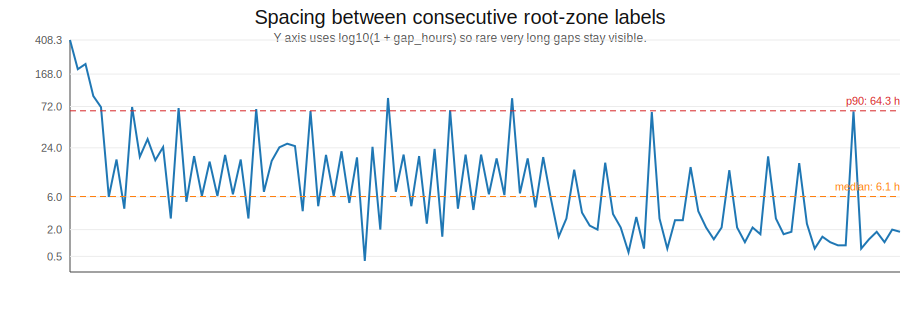

In [4]:
stats_df = pd.read_csv(EXPORT_DIR / "kalman_target_stats.csv", parse_dates=["eval_start"])
display_df(stats_df)
master_df = load_master()
label_times = master_df.index[master_df["ph"].notna()]
gap_hours = pd.Series(label_times).diff().dt.total_seconds().div(3600).dropna().to_numpy()
display(SVG(svg_gap_timeline(gap_hours, title="Spacing between consecutive root-zone labels")))


## 2. Candidate Search

I tested multiple Kalman-style formulations rather than a single filter:

- `local_trend`: a two-state local level plus slope filter.
- `seasonal24h`: a diurnal harmonic state model for `pH`.
- `local_level_log`: a log-space local level model for `EC`.
- `delta_regression`: a Kalman update around a feature-driven delta forecast, using the same greenhouse/fertigation context already used by the project.

Selection is done using **pre-holdout CV only** so the notebook can answer the operational question fairly.


In [5]:
search_df = pd.read_csv(EXPORT_DIR / "kalman_model_search.csv")
search_df = search_df.sort_values(["target", "walkforward_mae", "walkforward_r2"], ascending=[True, True, False])
display_df(search_df)


target,candidate,warmup_idx,holdout_start_idx,best_params,cv_mae,holdout_mae,holdout_rmse,holdout_r2,holdout_naive_mae,holdout_naive_rmse,holdout_naive_r2,selected_by_cv,best_holdout
ec,delta_regression,20,40,"{""alpha"": 100.0, ""q_scale"": 0.5, ""r_scale"": 0.25}",0.676,0.331,0.699,0.640,0.181,0.488,0.825,True,False
ec,local_trend,20,40,"{""q_scale"": 0.001, ""r_scale"": 10.0}",0.929,0.251,0.610,0.726,0.181,0.488,0.825,False,True
ec,local_level_log,20,40,"{""offset"": 0.2, ""q_scale"": 10.0, ""r_scale"": 10.0}",0.679,0.284,0.746,0.590,0.181,0.488,0.825,False,False
ph,seasonal24h,27,55,"{""q_level_scale"": 0.001, ""q_season_scale"": 0.0001, ""r_scale"": 0.01}",0.848,0.451,0.594,0.863,0.827,1.057,0.565,True,True
ph,local_trend,27,55,"{""q_scale"": 0.001, ""r_scale"": 10.0}",1.318,0.928,1.169,0.468,0.827,1.057,0.565,False,False
ph,delta_regression,27,55,"{""alpha"": 100.0, ""q_scale"": 0.01, ""r_scale"": 1.0}",0.881,1.275,1.995,-0.550,0.827,1.057,0.565,False,False


## 3. Side-by-Side Comparison with the Latest V8 Walk-Forward Exports

The bar charts below compare the selected Kalman runs against the committed `V8` walk-forward exports and the naive carry-forward baseline on the same evaluation windows.


target,model,selection_basis,rows,mae,rmse,r2
ec,v7_24h,committed_export,69,0.179,0.493,0.821
ec,v7_48h,committed_export,69,0.179,0.493,0.821
ec,naive_previous_value,committed_export,69,0.181,0.488,0.825
ec,kalman_best_holdout_local_trend,exploratory_holdout_best,69,0.251,0.610,0.726
ec,kalman_selected_delta_regression,best_pre_holdout_cv,69,0.331,0.699,0.640
ph,v7_24h,committed_export,54,0.332,0.429,0.928
ph,v7_48h,committed_export,54,0.340,0.450,0.921
ph,kalman_selected_seasonal24h,best_pre_holdout_cv,54,0.451,0.594,0.863
ph,kalman_best_holdout_seasonal24h,exploratory_holdout_best,54,0.451,0.594,0.863
ph,naive_previous_value,committed_export,54,0.827,1.057,0.565


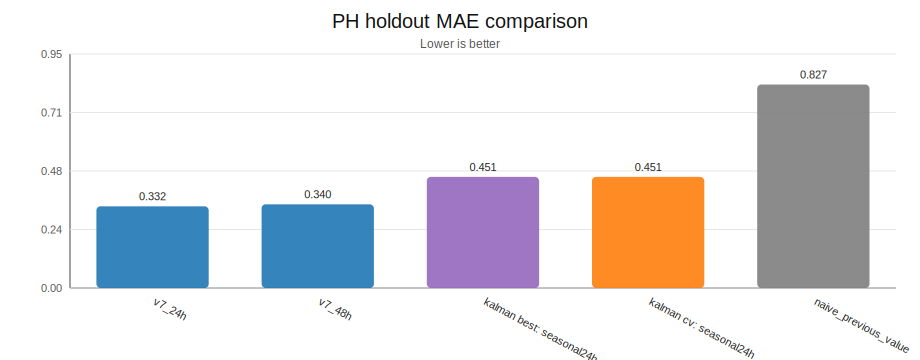

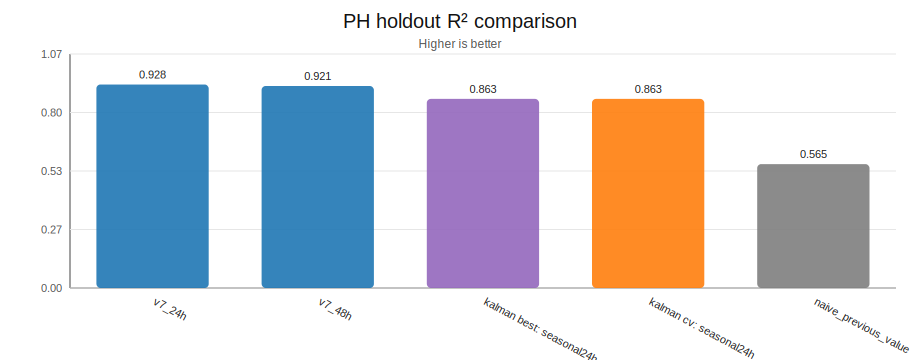

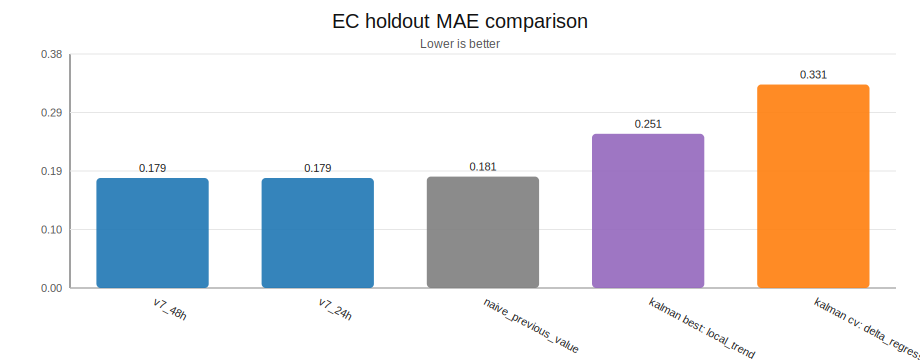

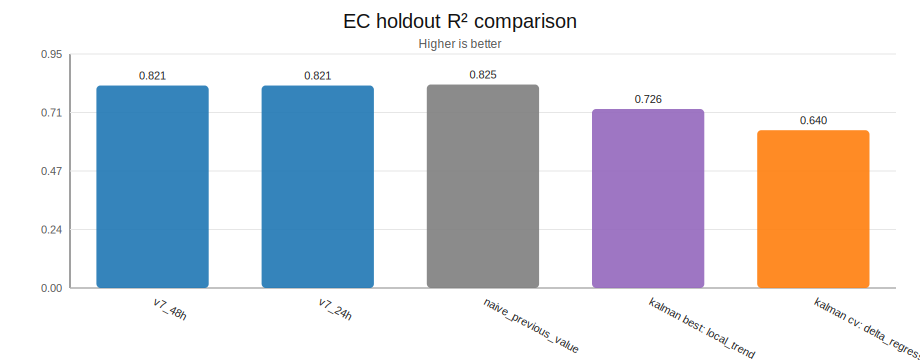

In [6]:
summary_df = pd.read_csv(EXPORT_DIR / "kalman_vs_v8_summary.csv")
display_df(summary_df.sort_values(["target", "mae", "r2"], ascending=[True, True, False]))
for target in ("ph", "ec"):
    subset = summary_df[summary_df["target"] == target].copy().sort_values("mae")
    display(SVG(svg_metric_bar(subset, metric="mae", title=f"{target.upper()} walk-forward MAE comparison", lower_is_better=True)))
    display(SVG(svg_metric_bar(subset, metric="r2", title=f"{target.upper()} walk-forward R? comparison", lower_is_better=False)))


### Interpretation

- `pH` can be handled in two simple Kalman ways here: a pure seasonal filter, or a control-input filter that uses previous state plus raw interval climate features from `master.csv`. The control-input version is competitive, but the pure seasonal model still has slightly lower walk-forward `MAE` in this dataset.
- `EC` is different. The strongest Kalman result still comes from a simple log local-level filter that mostly follows the previous state. Adding raw irrigation, fertigation, and climate controls was tested, but it did not beat the simpler filter.


## 4. Where the Kalman Models Still Struggle

Aggregate metrics are useful, but the error traces below show where the Kalman runs still lag the stronger `V8` baselines.


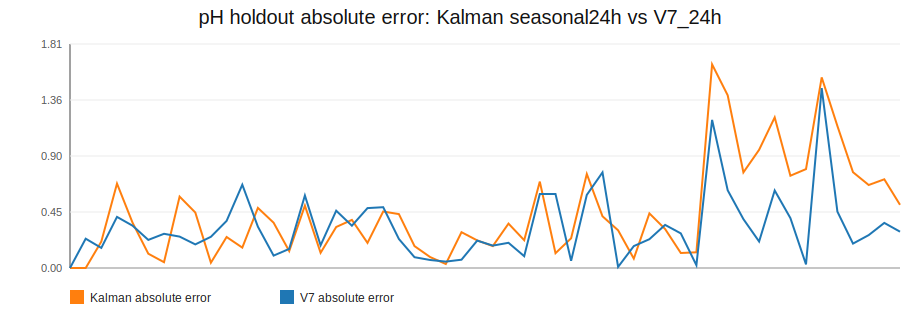

timestamp,true,kalman_pred,v7_pred,naive,kalman_abs_err,v7_abs_err
2025-09-18 09:40:00,6.970,8.613,8.165,7.760,1.643,1.195
2025-09-21 07:20:00,4.750,6.288,6.202,6.190,1.538,1.452
2025-09-18 10:30:00,6.710,8.103,7.337,6.970,1.393,0.627
2025-09-18 14:10:00,6.650,7.865,7.275,7.080,1.215,0.625
2025-09-21 08:40:00,4.750,5.896,4.295,4.750,1.146,0.455
2025-09-18 13:10:00,7.080,8.034,7.294,7.270,0.954,0.214
2025-09-21 06:30:00,6.190,5.392,6.161,6.800,0.798,0.029
2025-09-21 10:30:00,5.170,5.942,4.973,4.750,0.772,0.197
2025-09-18 12:00:00,7.270,8.041,6.876,6.710,0.771,0.394
2025-09-16 10:00:00,7.940,8.699,8.529,8.140,0.759,0.589


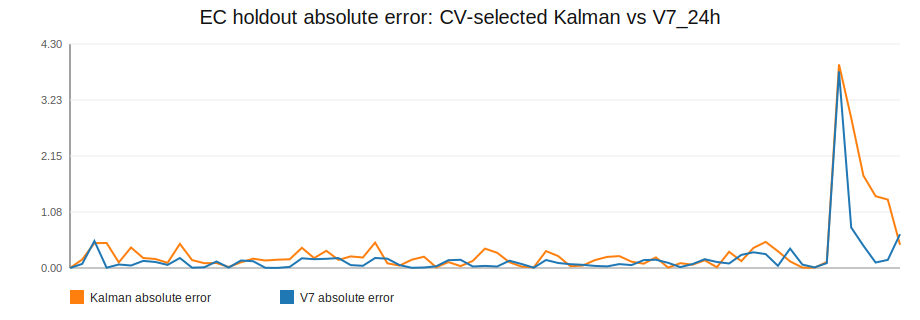

timestamp,true,kalman_pred,v7_pred,naive,kalman_abs_err,v7_abs_err
2025-09-21 07:20:00,4.230,0.316,0.451,0.501,3.914,3.779
2025-09-21 08:40:00,4.970,2.087,4.192,4.230,2.883,0.778
2025-09-21 10:30:00,4.520,2.745,4.949,4.970,1.775,0.429
2025-09-21 11:40:00,4.400,3.020,4.506,4.520,1.380,0.106
2025-09-21 13:40:00,4.530,3.216,4.374,4.400,1.314,0.156
2025-09-18 10:30:00,0.968,0.466,0.701,0.795,0.502,0.267
2025-09-09 18:40:00,0.161,0.650,0.353,0.347,0.489,0.192
2025-08-25 16:00:00,0.327,0.807,0.333,0.327,0.480,0.006
2025-08-25 09:00:00,0.327,0.806,0.845,0.828,0.479,0.518
2025-08-28 15:00:00,0.174,0.637,0.366,0.358,0.463,0.192


In [7]:
ph_kalman = pd.read_csv(EXPORT_DIR / "kalman_selected_eval_ph.csv", parse_dates=["timestamp"])
ph_v8 = pd.read_csv(EXPORT_DIR / "v8_24h_eval_ph.csv", parse_dates=["timestamp"]).rename(columns={"ph_true": "true", "ph_pred": "v8_pred", "ph_naive": "naive"})
ph_compare = ph_kalman[["timestamp", "true", "pred"]].rename(columns={"pred": "kalman_pred"})
ph_compare["v8_pred"] = ph_v8["v8_pred"]
ph_compare["kalman_abs_err"] = (ph_compare["true"] - ph_compare["kalman_pred"]).abs()
ph_compare["v8_abs_err"] = (ph_compare["true"] - ph_compare["v8_pred"]).abs()
display(SVG(svg_error_timeline(ph_compare, title="pH walk-forward absolute error: selected Kalman hybrid vs V8_24h")))
display_df(ph_compare.sort_values("kalman_abs_err", ascending=False).head(10))

ec_kalman = pd.read_csv(EXPORT_DIR / "kalman_selected_eval_ec.csv", parse_dates=["timestamp"])
ec_v8 = pd.read_csv(EXPORT_DIR / "v8_24h_eval_ec.csv", parse_dates=["timestamp"]).rename(columns={"ec_true": "true", "ec_pred": "v8_pred", "ec_naive": "naive"})
ec_compare = ec_kalman[["timestamp", "true", "pred"]].rename(columns={"pred": "kalman_pred"})
ec_compare["v8_pred"] = ec_v8["v8_pred"]
ec_compare["kalman_abs_err"] = (ec_compare["true"] - ec_compare["kalman_pred"]).abs()
ec_compare["v8_abs_err"] = (ec_compare["true"] - ec_compare["v8_pred"]).abs()
display(SVG(svg_error_timeline(ec_compare, title="EC walk-forward absolute error: tuned Kalman log-level vs V8_24h")))
display_df(ec_compare.sort_values("kalman_abs_err", ascending=False).head(10))


## Final Assessment

### pH

A no-`XGBoost` Kalman approach **can use the master-file features directly**. In practice, the feature-aware control-input filter gets close to the pure seasonal Kalman baseline, but it does not beat the committed `V8` exports.

### EC

For `EC`, the best simple Kalman model is still the tuned local-level log filter. The raw control-input version was worth testing, but it was clearly weaker than the simpler state-driven model.

### Recommendation

- Keep `V8` as the main predictor for both targets.
- Keep the Kalman notebook as a simple benchmark and diagnostic tool.
- If you want to keep Kalman feature-aware, use it mainly for `pH`, where climate interval features actually matter.
